# Install mesa


In [1]:
!pip install mesa -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 5.4 MB/s eta 0:00:00


# Import files

In [3]:
from google.colab import files
uploaded = files.upload()

Saving 0718_ARANGCO.csv to 0718_ARANGCO.csv
Saving 0718_CEBALLOS.csv to 0718_CEBALLOS.csv
Saving 0718_DELOSREYES.csv to 0718_DELOSREYES.csv
Saving 0718_F~1.CSV to 0718_F~1.CSV
Saving 0718_LINA.csv to 0718_LINA.csv
Saving 0718_NERI_withFuelData.csv to 0718_NERI_withFuelData.csv


# Load and clean data

In [88]:
import pandas as pd
import numpy as np
import io

print("Loading data...")

all_dfs = []
for fname, content in uploaded.items():
    if fname.endswith('.csv'):
        raw = pd.read_csv(io.BytesIO(content), low_memory=False)
        raw['source_file'] = fname
        all_dfs.append(raw)
        print(f"  Loaded: {fname} — {len(raw):,} rows")

df_all = pd.concat(all_dfs, ignore_index=True)

# Fix timestamp
df_all['timestamp'] = pd.to_datetime(df_all['timestamp'], errors='coerce')
df_all = df_all.dropna(subset=['timestamp'])
df_all = df_all.sort_values('timestamp').reset_index(drop=True)

# Clean continuous signals
df_all['Speed']     = df_all['Speed'].interpolate(method='linear')
df_all['latitude']  = df_all['latitude'].interpolate(method='linear')
df_all['longitude'] = df_all['longitude'].interpolate(method='linear')

# Clean boarding / alighting
df_all['Board']  = df_all['Board'].replace('False', 0).replace('TRUE', 1)
df_all['Alight'] = df_all['Alight'].replace('False', 0).replace('TRUE', 1)
df_all['Board']  = pd.to_numeric(df_all['Board'],  errors='coerce').fillna(0)
df_all['Alight'] = pd.to_numeric(df_all['Alight'], errors='coerce').fillna(0)

# Occupancy — carry last known value forward
df_all['Numpass'] = pd.to_numeric(df_all['Numpass'], errors='coerce').ffill().fillna(0)

# Time index in minutes from trip start
df_all['minute'] = (df_all['timestamp'] - df_all['timestamp'].min()).dt.total_seconds() // 60

print(f"\nData ready. Total rows: {len(df_all):,}")
print(f"Total passengers boarded: {int(df_all['Board'].sum())}")
print(f"Max bus occupancy recorded: {int(df_all['Numpass'].max())}")

Loading data...
  Loaded: 0718_ARANGCO.csv — 32,227 rows
  Loaded: 0718_CEBALLOS.csv — 48,572 rows
  Loaded: 0718_DELOSREYES.csv — 56,441 rows
  Loaded: 0718_LINA.csv — 27,751 rows
  Loaded: 0718_NERI_withFuelData.csv — 57,246 rows

Data ready. Total rows: 222,230
Total passengers boarded: 2219
Max bus occupancy recorded: 84


# Extract station stops

In [89]:
stopped_df = df_all[df_all['Speed'] <= 3].copy()
# <= 3 better than == 0 to capture other idle stops as well
# group consecutive stopped seconds into single station stops
# A gap of more than 60 seconds between stops means it's a new stop
stopped_df['time_diff']   = stopped_df['timestamp'].diff().dt.total_seconds()
stopped_df['is_new_stop'] = (stopped_df['time_diff'] > 60) | (stopped_df['time_diff'].isna())
stopped_df['stop_id']     = stopped_df['is_new_stop'].cumsum()

# Calculate stats per stop
stop_stats = stopped_df.groupby('stop_id').agg(
    arrival_time   = ('timestamp', 'min'),
    departure_time = ('timestamp', 'max'),
    total_boarded  = ('Board', 'sum'),
    lat            = ('latitude', 'mean'),
    lon            = ('longitude', 'mean')
)
stop_stats['dwell_time_mins'] = (
    (stop_stats['departure_time'] - stop_stats['arrival_time']).dt.total_seconds() / 60.0
)

# Require minimum dwell time of 20 seconds (0.33 mins) to filter out traffic/intersection crawls
station_stops = stop_stats[(stop_stats['total_boarded'] > 0) & (stop_stats['dwell_time_mins'] >= (20/60))].copy()

# Top 5 busiest stops
top_bottlenecks = station_stops.sort_values(by='total_boarded', ascending=False).head(5)

print("TOP 5 BUSIEST STATION STOPS")
print("-" * 50)
for idx, row in top_bottlenecks.iterrows():
    print(f"Time: {row['arrival_time']}")
    print(f"Total Boarded (λ): {row['total_boarded']} passengers")
    print(f"Dwell Time (μ): {row['dwell_time_mins']:.2f} minutes")
    print(f"GPS: {row['lat']:.5f}, {row['lon']:.5f}")
    print("-" * 50)

TOP 5 BUSIEST STATION STOPS
--------------------------------------------------
Time: 2023-07-18 10:23:58
Total Boarded (λ): 1371.0 passengers
Dwell Time (μ): 752.32 minutes
GPS: 14.57510, 121.01150
--------------------------------------------------
Time: 2023-07-18 07:06:55
Total Boarded (λ): 349.0 passengers
Dwell Time (μ): 195.90 minutes
GPS: 14.57017, 121.01014
--------------------------------------------------
Time: 2023-07-18 06:01:30
Total Boarded (λ): 229.0 passengers
Dwell Time (μ): 64.17 minutes
GPS: 14.64065, 121.01952
--------------------------------------------------
Time: 2023-07-18 05:54:51
Total Boarded (λ): 31.0 passengers
Dwell Time (μ): 5.58 minutes
GPS: 14.65477, 121.02442
--------------------------------------------------
Time: 2023-07-18 05:17:50
Total Boarded (λ): 17.0 passengers
Dwell Time (μ): 2.78 minutes
GPS: 14.55007, 121.02884
--------------------------------------------------


# Mapping stops to stations


In [90]:
STATIONS = {
    "Monumento": {"lat": 14.6543, "lon": 120.9838},
    "North Ave": {"lat": 14.6525, "lon": 121.0315},
    "Quezon Ave":{"lat": 14.6433, "lon": 121.0388},
    "Main Ave":  {"lat": 14.6148, "lon": 121.0519},
    "Santolan":  {"lat": 14.6074, "lon": 121.0543},
    "Ortigas":   {"lat": 14.5878, "lon": 121.0566},
    "Guadalupe": {"lat": 14.5683, "lon": 121.0455},
    "Buendia":   {"lat": 14.5539, "lon": 121.0331},
    "Ayala":     {"lat": 14.5492, "lon": 121.0284},
    "Taft":      {"lat": 14.5374, "lon": 120.9992},
    "PITX":      {"lat": 14.5111, "lon": 120.9913}
}
STATION_ORDER = list(STATIONS.keys())
N_STATIONS    = len(STATION_ORDER)

# Haversine formula
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2   = np.radians(lat1), np.radians(lat2)
    delta_phi    = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

def identify_station(row):
    for name, coords in STATIONS.items():
        if calculate_distance(row['lat'], row['lon'], coords['lat'], coords['lon']) <= 250:
            return name
    return None

station_stops['true_station'] = station_stops.apply(identify_station, axis=1)
verified = station_stops[station_stops['true_station'].notna()].copy()

# Average parameters per station
station_params = verified.groupby('true_station').agg(
    total_stops            = ('true_station', 'count'),
    avg_passengers_boarded = ('total_boarded', 'mean'),
    avg_dwell_mins         = ('dwell_time_mins', 'mean')
).reset_index().sort_values(by='avg_dwell_mins', ascending=False)

print("-" * 60)
print(station_params.to_string(index=False))

------------------------------------------------------------
true_station  total_stops  avg_passengers_boarded  avg_dwell_mins
        Taft            1                    12.0        6.316667
    Main Ave            2                     8.5        3.583333
       Ayala            1                    17.0        2.783333
        PITX            1                    12.0        1.166667


# Model Parameters

In [91]:
file_names  = list(uploaded.keys())
n_train     = 6
train_files = set(file_names[:n_train])

print(f"Train files ({len(train_files)}): {sorted(train_files)}")

df_train = df_all[df_all['source_file'].isin(train_files)].copy()

# arrival pattern = boardings per minute from the training data
arrival_by_minute = df_train.groupby('minute')['Board'].sum()
ARRIVAL_RATE = max(1, arrival_by_minute.mean())
# simulation parameters from the data
arrival_pattern = arrival_by_minute.to_dict()

# simulation parameters assigned
ABANDON_WAIT    = 30 #set only
BUS_CAPACITY    = 60 # based on bus capacity
SIM_STEPS       = 120 # 2 hour simulation
FIXED_INTERVAL  = 15 # estimated intervals based on web data
HEADWAY_GAP     = 10 # estimated also based on web data
QUEUE_THRESHOLD = int(BUS_CAPACITY * 0.5)
MAX_DWELL = 3
# source: https://edsacarousel.com/bus-schedule

# boarding/service rate, passengers loaded per minute per bus
# if len(verified) > 0 and verified['dwell_time_mins'].sum() > 0:
#     LOAD_RATE = max(1, int(verified['total_boarded'].sum() / verified['dwell_time_mins'].sum()))
# else:
#     LOAD_RATE = 12

# commented out because obtained load_rate of buses doesn't seem realistic enough
LOAD_RATE = 12
MU_SERVICE_RATE = LOAD_RATE
print(f"Arrival rate λ: {ARRIVAL_RATE:.2f} pax/min")
print(f"Load/service rate μ: {LOAD_RATE} pax/min/bus")

# random dispatch intervals from first observed station arrival per bus
STOCHASTIC_DISPATCH_INTERVALS = np.random.normal(
    loc=FIXED_INTERVAL,
    scale=3,
    size=25 #around that number of buses per 120 simulation run
)
STOCHASTIC_DISPATCH_INTERVALS = [
    max(3, int(round(x, 1)))
    for x in STOCHASTIC_DISPATCH_INTERVALS
]
print("Real-world/empirical intervals:", STOCHASTIC_DISPATCH_INTERVALS)

print("\nFinal parameters:")
print(f"Arrival rate (λ):      {ARRIVAL_RATE} pax/min")
print(f"Service rate (μ):      {MU_SERVICE_RATE:.2f} pax/min")
print(f"Load rate:             {LOAD_RATE} pax/min/bus")
print(f"Abandon wait:          {ABANDON_WAIT} min")
print(f"Queue threshold:       {QUEUE_THRESHOLD} pax")
print(f"Random intervals:  {STOCHASTIC_DISPATCH_INTERVALS}")

Train files (6): ['0718_ARANGCO.csv', '0718_CEBALLOS.csv', '0718_DELOSREYES.csv', '0718_F~1.CSV', '0718_LINA.csv', '0718_NERI_withFuelData.csv']
Arrival rate λ: 1.93 pax/min
Load/service rate μ: 12 pax/min/bus
Real-world/empirical intervals: [13, 12, 15, 13, 14, 13, 5, 16, 13, 12, 12, 21, 20, 16, 15, 11, 16, 12, 11, 17, 19, 12, 17, 20, 15]

Final parameters:
Arrival rate (λ):      1.9312445604873802 pax/min
Service rate (μ):      12.00 pax/min
Load rate:             12 pax/min/bus
Abandon wait:          30 min
Queue threshold:       30 pax
Random intervals:  [13, 12, 15, 13, 14, 13, 5, 16, 13, 12, 12, 21, 20, 16, 15, 11, 16, 12, 11, 17, 19, 12, 17, 20, 15]


# ABMs and Environment

In [92]:
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Passenger Agent
# states: waiting / abandoned
# > increased waiting time per step
# behavior: abandon queue if waiting time threshold is met
class PassengerAgent(mesa.Agent):
    def __init__(self, model, station_idx):
        super().__init__(model)
        self.station_idx = station_idx
        self.wait_time   = 0
        self.abandoned   = False

    def step(self):
        if self.abandoned:
            return
        self.wait_time += 1
        if self.wait_time > ABANDON_WAIT:
            self.abandoned = True
            self.model.abandoned_count += 1
            self.model.station_queues[self.station_idx].discard(self)


# Bus Agent
# states: loading / moving / done
# behavior: load passengers then follow a specific dispatching behavior
class BusAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.station_idx  = 0
        self.capacity     = BUS_CAPACITY
        self.status       = 'loading'
        self.move_timer   = 0
        self.dwell_timer  = 0

    def step(self):
        if self.status == 'done':
            return

        if self.status == 'loading':
            queue   = list(self.model.station_queues[self.station_idx])
            to_load = min(LOAD_RATE, len(queue), self.capacity)
            for p in queue[:to_load]:
                self.model.total_wait_time_served += p.wait_time
                self.model.served_count += 1
                self.model.station_queues[self.station_idx].discard(p)
                self.capacity -= 1

            queue_left = self.model._queue_len(self.station_idx)
            if (
                queue_left > 0
                and self.capacity > 0
                and self.dwell_timer < MAX_DWELL
            ):
                return
            # leave station
            if self.station_idx < N_STATIONS - 1:
                self.move_timer = 4
                self.status = 'moving'
            else:
                self.status = 'done'
                self.model.buses_done += 1

        elif self.status == 'moving':
            self.move_timer -= 1
            if self.move_timer <= 0:
                self.station_idx += 1
                self.status       = 'loading'
                self.dwell_timer  = 0

# Environment Model

class EDSABuswayModel(mesa.Model):
    def __init__(self, strategy, arrival_rate=None, rng=42):
        super().__init__(rng=rng)
        self.strategy      = strategy
        self.arrival_rate  = arrival_rate if arrival_rate is not None else ARRIVAL_RATE
        self.steps         = 0

        self.served_count           = 0
        self.abandoned_count        = 0
        self.buses_dispatched       = 0
        self.buses_done             = 0
        self.total_wait_time_served = 0
        self.last_dispatch          = -999
        self.total_passengers_arrived = 0
        self.headways               = []

        # Load baseline stochastic intervals for random
        self.empirical_intervals    = STOCHASTIC_DISPATCH_INTERVALS.copy()
        self.next_real_gap          = self.empirical_intervals.pop(0) if self.empirical_intervals else FIXED_INTERVAL

        self.station_queues = [set() for _ in range(N_STATIONS)]

        self.queue_history     = []
        self.served_history    = []
        self.abandoned_history = []
        self.avg_wait_history  = []
        self.bunching_history  = []

    def _queue_len(self, idx=0):
        return len([p for p in self.station_queues[idx] if not p.abandoned])

    def _spawn_passengers(self):
        lam = arrival_pattern.get(self.steps, self.arrival_rate)
        n = np.random.poisson(lam)
        self.total_passengers_arrived += n
        for _ in range(n):
            p = PassengerAgent(self, station_idx=0)
            self.station_queues[0].add(p)
            self.agents.add(p)

    def _should_dispatch(self):
        gap    = self.steps - self.last_dispatch if self.last_dispatch != -999 else self.steps
        pitx_q = self._queue_len(0)

        if self.strategy == 'fixed':
            return gap >= FIXED_INTERVAL

        elif self.strategy == 'headway':
            return pitx_q > 0 and gap >= HEADWAY_GAP

        elif self.strategy == 'queue':
          soft_threshold = int(BUS_CAPACITY * 0.35)
             # dispatch when queue is high, but still prevent unrealistic bus spam
          if pitx_q >= QUEUE_THRESHOLD and gap >= 3:
              return True
          if pitx_q >= soft_threshold and gap >= HEADWAY_GAP:
              return True
          # fallback service so passengers are not left waiting too long
          return pitx_q > 5 and gap >= HEADWAY_GAP

        elif self.strategy == 'random':
            return gap >= self.next_real_gap

        return False

    def _dispatch_bus(self):
        b = BusAgent(self)
        self.agents.add(b)
        self.buses_dispatched += 1
        self.last_dispatch     = self.steps

        if self.strategy == 'random':
            # Cycle empirical gaps
            self.empirical_intervals.append(self.next_real_gap)
            self.next_real_gap = self.empirical_intervals.pop(0)

    def step(self):
        self._spawn_passengers()

        # Calculate bunching exactly at dispatch based on headway collapse
        bunching_this_step = 0
        if self._should_dispatch():
            if self.last_dispatch != -999:
                hw = self.steps - self.last_dispatch
                self.headways.append(hw)
                # Bunching defined as headway less than 50% of the scheduled fixed baseline interval
                if hw < (0.5 * FIXED_INTERVAL):
                    bunching_this_step = 1
            self._dispatch_bus()

        self.agents.do('step')

        self.queue_history.append(self._queue_len(0))
        self.served_history.append(self.served_count)
        self.abandoned_history.append(self.abandoned_count)
        avg_w = (self.total_wait_time_served / self.served_count if self.served_count > 0 else 0)
        self.avg_wait_history.append(avg_w)
        self.bunching_history.append(bunching_this_step)

        self.steps += 1

# Results: Summary table

In [93]:
# run 4 strategies

print("Running simulations...")
models = {}
STRATEGIES = ['fixed', 'headway', 'queue', 'random']
for strategy in STRATEGIES:
    m = EDSABuswayModel(strategy=strategy, arrival_rate=ARRIVAL_RATE)
    for _ in range(SIM_STEPS):
        m.step()
    models[strategy] = m
    print(f"  {strategy}: served={m.served_count}, abandoned={m.abandoned_count}, buses={m.buses_dispatched}")

print("Done.")

records = []
for strategy, m in models.items():
    avg_wait = m.total_wait_time_served / m.served_count if m.served_count > 0 else 0
    peak_q = max(m.queue_history) if m.queue_history else 1

    # Efficiency Metrics
    throughput = m.served_count / max(1, m.total_passengers_arrived)
    sei = m.served_count / ((avg_wait + 1) * peak_q)

    # Bunching Metrics
    bunching_events = sum(m.bunching_history)
    bunching_rate = bunching_events / max(1, m.buses_dispatched)
    avg_hw = np.mean(m.headways) if m.headways else 0

    # Utilization
    mu_eff = (BUS_CAPACITY * m.buses_dispatched ) / SIM_STEPS
    rho = ARRIVAL_RATE / mu_eff

    records.append({
        'Strategy':                  strategy.capitalize(),
        'Average Wait Time':         round(avg_wait, 2),
        'Peak Queue Length':         peak_q,
        'Passengers Served':         m.served_count,
        'Passenger Abandonment':     m.abandoned_count,
        'Throughput Efficiency':     round(throughput, 3),
        'Service Efficiency Index':  round(sei, 3),
        'Bunching Events':           bunching_events,
        'Bunching Rate':             round(bunching_rate, 3),
        'Average Headway':           round(avg_hw, 2),
        'Utilization':               round(rho, 3)
    })

summary_df = pd.DataFrame(records).set_index('Strategy')
print("FINAL SIMULATION RESULTS COMPARISON")
print("=" * 110)
print(summary_df.to_string())
print("=" * 110)
efficiency_rank = summary_df.sort_values(
    by=['Average Wait Time', 'Peak Queue Length', 'Bunching Rate'],
    ascending=[True, True, True]
)
print("BEST STRATEGY BASED ON LOWER WAIT TIME, LOWER QUEUE, AND LESS BUNCHING:")
print(efficiency_rank[['Average Wait Time', 'Peak Queue Length', 'Bunching Rate', 'Throughput Efficiency']])

Running simulations...
  fixed: served=253, abandoned=209, buses=15
  headway: served=226, abandoned=188, buses=21
  queue: served=235, abandoned=190, buses=15
  random: served=272, abandoned=230, buses=16
Done.
FINAL SIMULATION RESULTS COMPARISON
          Average Wait Time  Peak Queue Length  Passengers Served  Passenger Abandonment  Throughput Efficiency  Service Efficiency Index  Bunching Events  Bunching Rate  Average Headway  Utilization
Strategy                                                                                                                                                                                               
Fixed                  4.41                 43                253                    209                  1.000                     1.088                0          0.000             16.0        0.257
Headway                3.13                 27                226                    188                  1.000                     2.025               

# Results: Queue, Wait time, Served, Abandoned

---



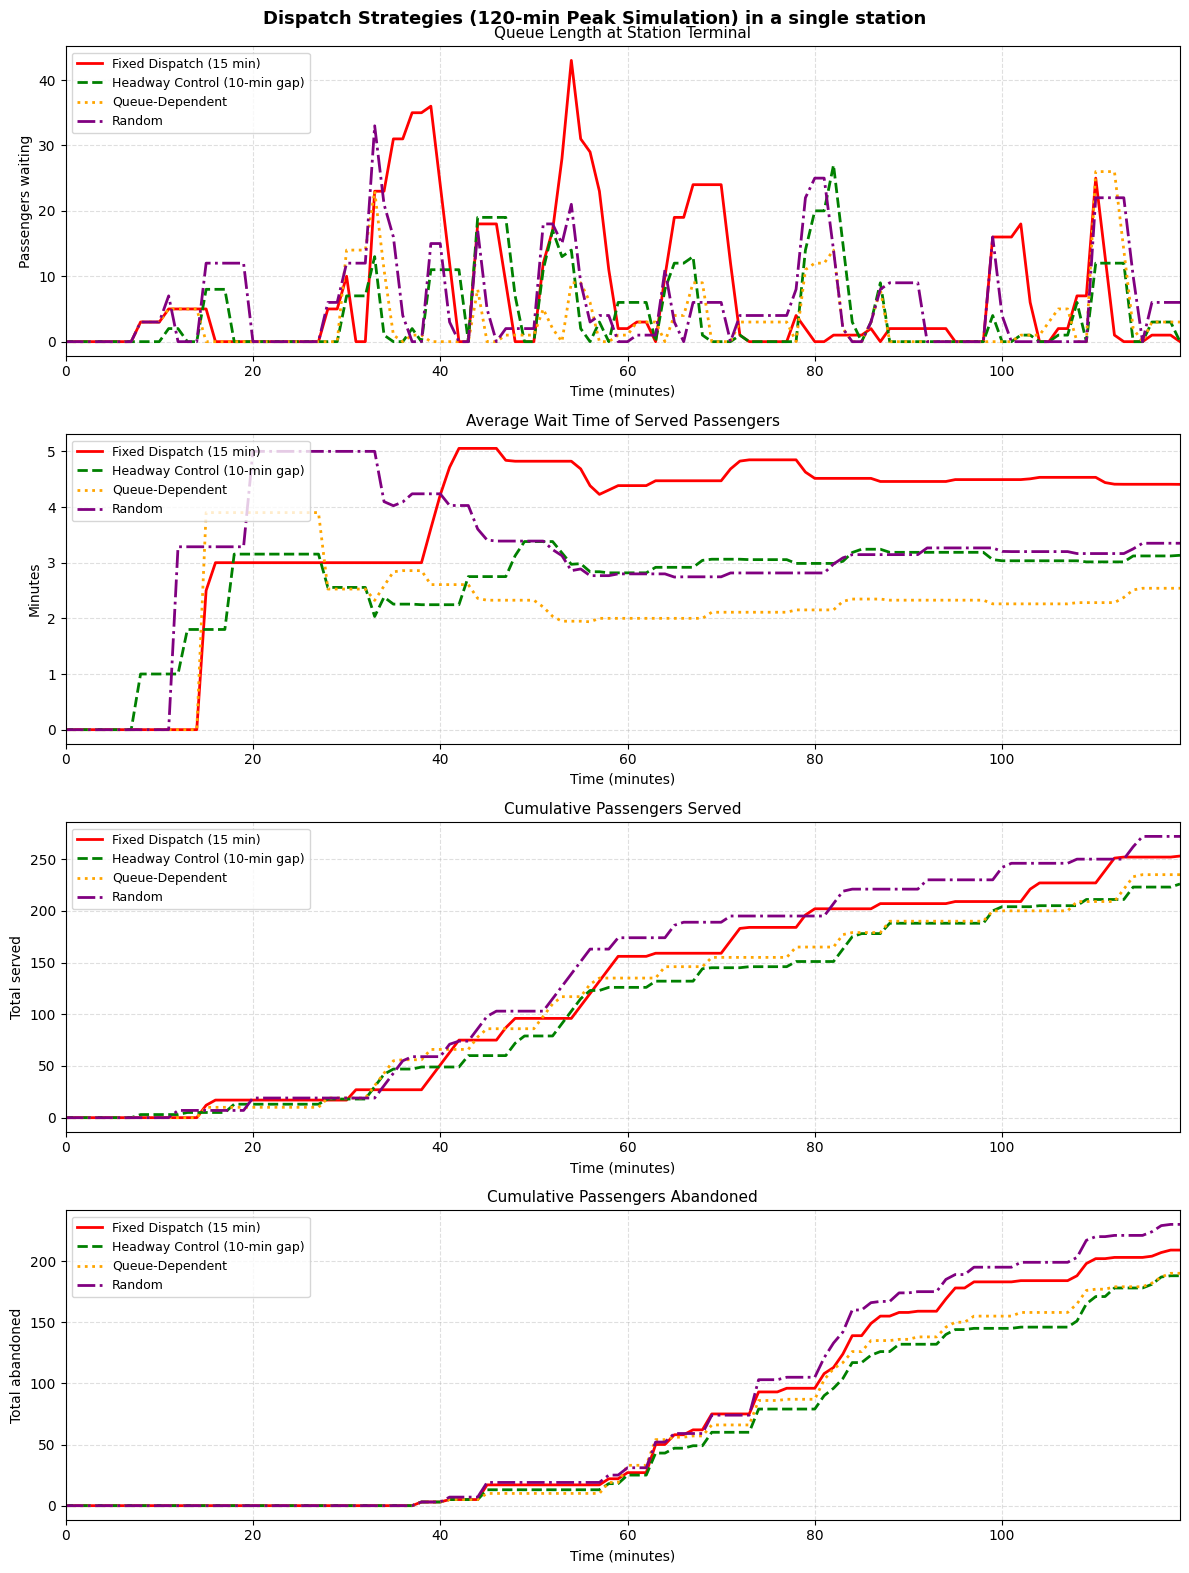

In [94]:
COLORS = {'fixed': 'red', 'headway': 'green', 'queue': 'orange', 'random': 'purple'}
STYLES = {'fixed': '-',   'headway': '--',    'queue': ':',      'random': '-.'}
NAMES  = {
    'fixed':      'Fixed Dispatch (15 min)',
    'headway':    'Headway Control (10-min gap)',
    'queue':      'Queue-Dependent',
    'random': 'Random',
}

fig, axes = plt.subplots(4, 1, figsize=(12, 16))
fig.suptitle('Dispatch Strategies (120-min Peak Simulation) in a single station', fontsize=13, fontweight='bold')

plot_config = [
    ('queue_history',     'Queue Length at Station Terminal',          'Passengers waiting'),
    ('avg_wait_history',  'Average Wait Time of Served Passengers',    'Minutes'),
    ('served_history',    'Cumulative Passengers Served',              'Total served'),
    ('abandoned_history', 'Cumulative Passengers Abandoned',           'Total abandoned'),
]

for ax, (attr, title, ylabel) in zip(axes, plot_config):
    for strategy, m in models.items():
        y = getattr(m, attr)
        ax.plot(range(len(y)), y, color=COLORS[strategy], linestyle=STYLES[strategy],
                linewidth=2, label=NAMES[strategy])
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel('Time (minutes)', fontsize=10)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlim(0, SIM_STEPS - 1)

plt.tight_layout()
plt.show()

Some notes: results vary each run but the overall pattern observed is the following:


1.   Queue length from shortest to highest is ranked by:
  

*   Fixed dispatch rate
*   Random
*   Headway control
*   Queue dependent


2.   Average wait time from shortest to longest is ranked by:


*   Queue dependent
*   Headway control
*   Random
*   Fixed dispatch rate.

    Remark: Queue dependent and headway control dispatch strategies show less average waiting time of passengers in the queue compared to fixed and random dispatch rates.

3. Cumulative passengers have almost the same rising graph with some minimal differences among their numbers.

4. Cumulative passenger abandonded also has the same slope and progession with also minimal difference with other metrics that was tested.





# Results: if Bus Bunching is significant
Bus bunching by definition the scenaio when multiple buses stay at a station affecting waiting time of passengers who will spawn in that station after the bus leaves.

/tmp/ipykernel_28819/3797484644.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(headway_data, patch_artist=True, labels=[s.capitalize() for s in STRATEGIES])


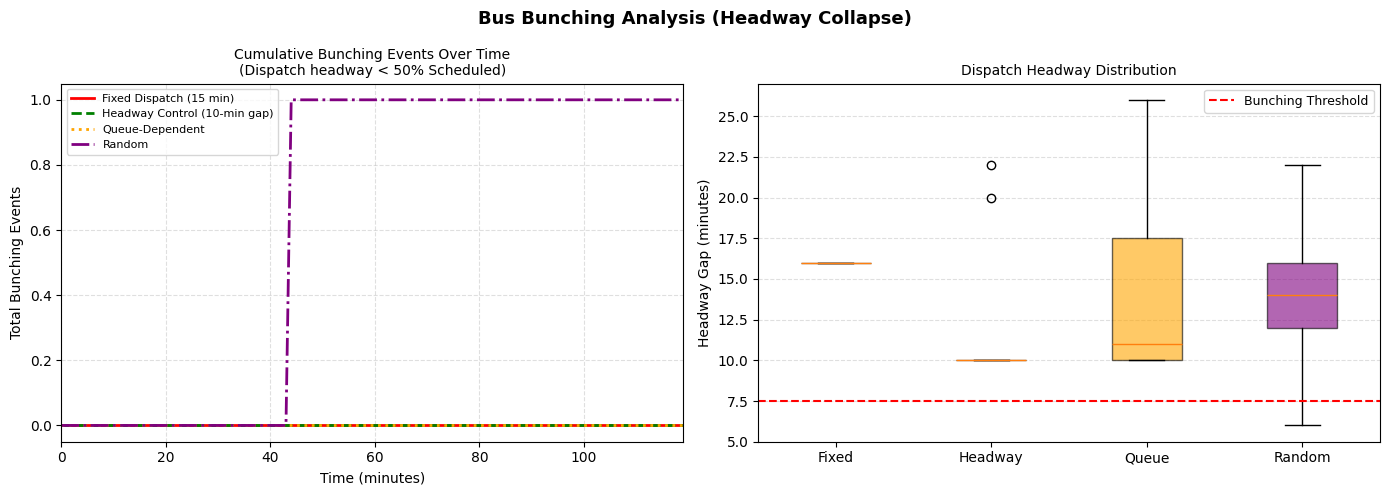

In [95]:
# if bus bunching exists, run this cell to create a graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bus Bunching Analysis (Headway Collapse)', fontsize=13, fontweight='bold')

# Left: Cumulative bunching events over time
ax = axes[0]
for strategy, m in models.items():
    cumulative_bunching = np.cumsum(m.bunching_history)
    ax.plot(range(len(cumulative_bunching)), cumulative_bunching,
            color=COLORS[strategy], linestyle=STYLES[strategy],
            linewidth=2, label=NAMES[strategy])
ax.set_title('Cumulative Bunching Events Over Time\n(Dispatch headway < 50% Scheduled)', fontsize=10)
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Total Bunching Events')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(0, SIM_STEPS - 1)

# Right: Average Headway Boxplot (Visualizing Headway Variance and bunching proximity)
ax2 = axes[1]
headway_data = [m.headways for m in models.values()]
bp = ax2.boxplot(headway_data, patch_artist=True, labels=[s.capitalize() for s in STRATEGIES])
for patch, color in zip(bp['boxes'], [COLORS[s] for s in STRATEGIES]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.axhline(0.5 * FIXED_INTERVAL, color='red', linestyle='--', label='Bunching Threshold')
ax2.set_title('Dispatch Headway Distribution', fontsize=10)
ax2.set_ylabel('Headway Gap (minutes)')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Results: Application of Server utilization from Queueing Theory (ρ)

In [96]:
lam = ARRIVAL_RATE
mu  = MU_SERVICE_RATE

print("QUEUEING THEORY PARAMETERS")
print("-" * 50)
print(f"λ (arrival rate):        {lam:.2f} pax/min")
print(f"μ (service rate):        {mu:.2f} pax/min per bus")
print()

qt_records = []
for strategy, m in models.items():
    dispatch_rate = m.buses_dispatched / SIM_STEPS  # buses per minute
    mu_eff = BUS_CAPACITY * dispatch_rate           # pax/min capacity supplied
    rho = lam / max(mu_eff, 0.01)

    if rho < 1:
        W_q_theory = rho / (2 * mu_eff * (1 - rho))
    else:
        W_q_theory = float('inf')

    sim_avg_wait = m.total_wait_time_served / m.served_count if m.served_count > 0 else 0

    qt_records.append({
        'Strategy':             strategy.capitalize(),
        'μ_eff (pax/min)':      round(mu_eff, 3),
        'ρ (utilization)':      round(rho, 3),
        'System Status':        'Stable' if rho < 1 else 'SATURATED',
        'W_q Theory (min)':     round(W_q_theory, 2) if rho < 1 else 'Inf',
        'W_q Simulated (min)':  round(sim_avg_wait, 2),
    })

qt_df = pd.DataFrame(qt_records).set_index('Strategy')
print("QUEUEING THEORY RESULTS")
print("=" * 75)
print(qt_df.to_string())
print("=" * 75)

QUEUEING THEORY PARAMETERS
--------------------------------------------------
λ (arrival rate):        1.93 pax/min
μ (service rate):        12.00 pax/min per bus

QUEUEING THEORY RESULTS
          μ_eff (pax/min)  ρ (utilization) System Status  W_q Theory (min)  W_q Simulated (min)
Strategy                                                                                       
Fixed                 7.5            0.257        Stable              0.02                 4.41
Headway              10.5            0.184        Stable              0.01                 3.13
Queue                 7.5            0.257        Stable              0.02                 2.54
Random                8.0            0.241        Stable              0.02                 3.35


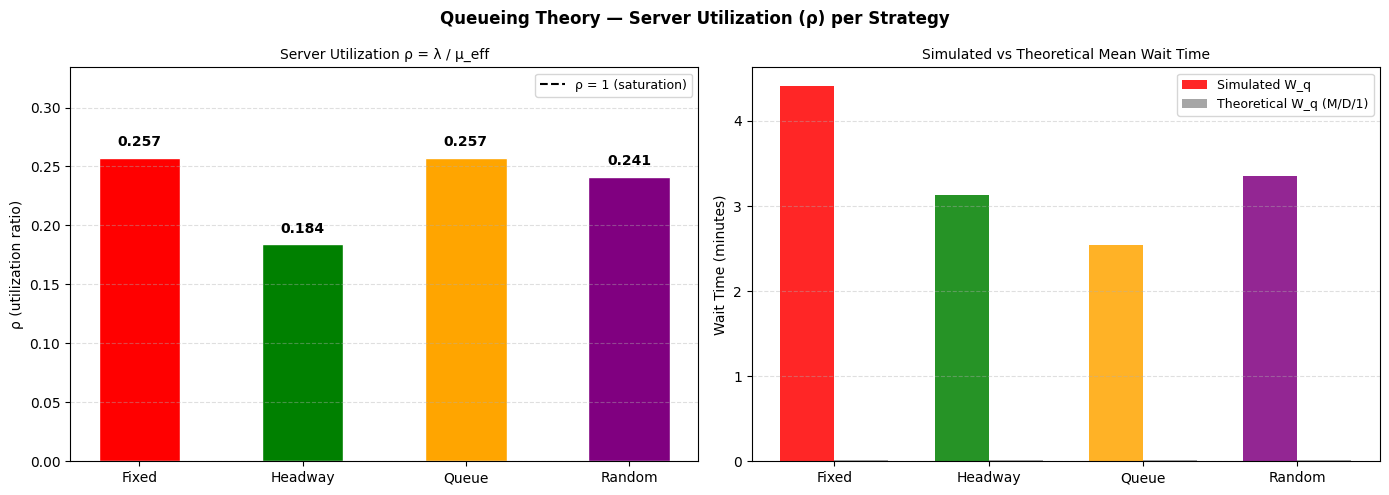

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Queueing Theory — Server Utilization (ρ) per Strategy', fontsize=12, fontweight='bold')

strats    = [r['Strategy'] for r in qt_records]
rho_vals  = [float(r['ρ (utilization)']) for r in qt_records]
wq_sim    = [float(r['W_q Simulated (min)']) for r in qt_records]
wq_theory = [float(r['W_q Theory (min)']) if r['W_q Theory (min)'] != 'Inf' else None for r in qt_records]

ax = axes[0]
bar_c = [COLORS[s.lower()] if s.lower() in COLORS else 'blue' for s in strats]
bars  = ax.bar(strats, rho_vals, color=bar_c, edgecolor='white', width=0.5)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='ρ = 1 (saturation)')
for bar, val in zip(bars, rho_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Server Utilization ρ = λ / μ_eff', fontsize=10)
ax.set_ylabel('ρ (utilization ratio)')
ax.set_ylim(0, max(rho_vals) * 1.3)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax2   = axes[1]
x     = np.arange(len(strats))
width = 0.35
ax2.bar(x - width/2, wq_sim, width, label='Simulated W_q', color=bar_c, alpha=0.85)
valid_theory = [v if v is not None else 0 for v in wq_theory]
ax2.bar(x + width/2, valid_theory, width, label='Theoretical W_q (M/D/1)', color='gray', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(strats)
ax2.set_title('Simulated vs Theoretical Mean Wait Time', fontsize=10)
ax2.set_ylabel('Wait Time (minutes)')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Results: Stress test with different arrival rates

In [98]:
RATE_SCENARIOS = {
    'Low (0.5x)':    int(ARRIVAL_RATE * 0.5),
    'Medium (1.0x)': ARRIVAL_RATE,
    'High (2.0x)':   int(ARRIVAL_RATE * 2.0),
}

print("Running arrival rate sensitivity analysis...")
sensitivity_results = {}

for rate_label, rate in RATE_SCENARIOS.items():
    sensitivity_results[rate_label] = {}
    for strategy in STRATEGIES:
        m = EDSABuswayModel(strategy=strategy, arrival_rate=rate)
        for _ in range(SIM_STEPS):
            m.step()
        sensitivity_results[rate_label][strategy] = m
    print(f"  {rate_label}: done")

Running arrival rate sensitivity analysis...
  Low (0.5x): done
  Medium (1.0x): done
  High (2.0x): done


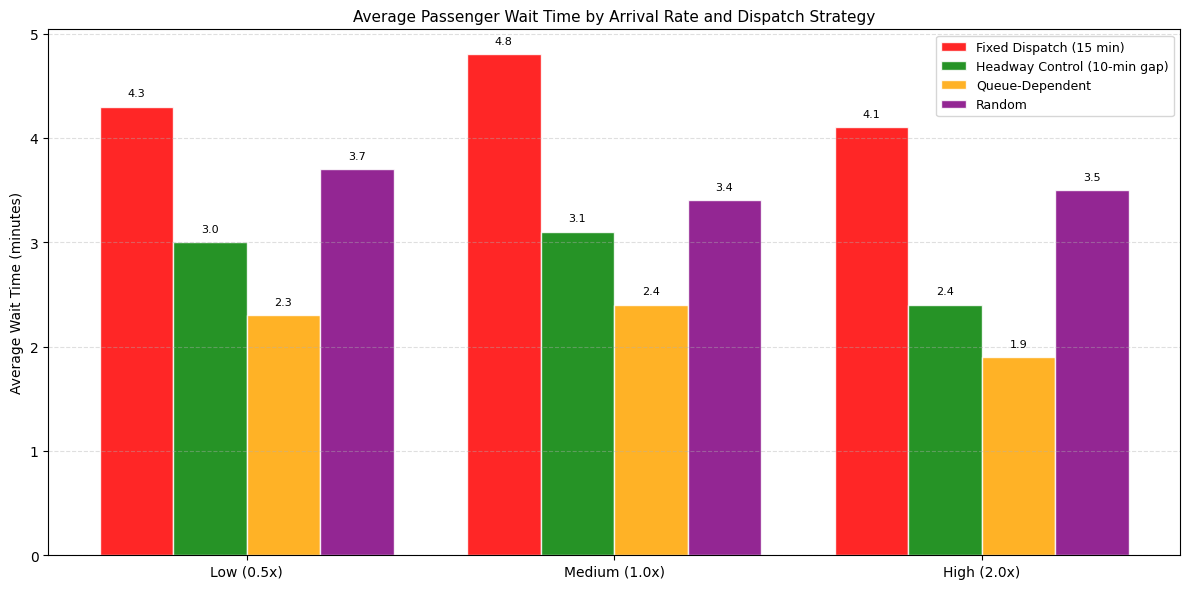


SENSITIVITY SUMMARY — Avg Wait Time (min) per Strategy
----------------------------------------------------------------------
               Fixed  Headway  Queue  Random
Arrival Rate                                
Low (0.5x)       4.3      3.0    2.3     3.7
Medium (1.0x)    4.8      3.1    2.4     3.4
High (2.0x)      4.1      2.4    1.9     3.5


In [99]:
fig, ax = plt.subplots(figsize=(12, 6))
rate_labels = list(RATE_SCENARIOS.keys())
x = np.arange(len(rate_labels))
width = 0.2
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

for offset, strategy in zip(offsets, STRATEGIES):
    avg_waits = []
    for rate_label in rate_labels:
        m = sensitivity_results[rate_label][strategy]
        w = m.total_wait_time_served / m.served_count if m.served_count > 0 else 0
        avg_waits.append(round(w, 1))
    bars = ax.bar(x + offset, avg_waits, width,
                  label=NAMES[strategy], color=COLORS[strategy], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, avg_waits):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(rate_labels)
ax.set_ylabel('Average Wait Time (minutes)')
ax.set_title('Average Passenger Wait Time by Arrival Rate and Dispatch Strategy', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("\nSENSITIVITY SUMMARY — Avg Wait Time (min) per Strategy")
print("-" * 70)
rows = []
for rate_label in rate_labels:
    row = {'Arrival Rate': rate_label}
    for strategy in STRATEGIES:
        m = sensitivity_results[rate_label][strategy]
        w = m.total_wait_time_served / m.served_count if m.served_count > 0 else 0
        row[strategy.capitalize()] = round(w, 1)
    rows.append(row)
print(pd.DataFrame(rows).set_index('Arrival Rate').to_string())

Remark: The reduction in average wait time observed under high demand for fixed and headway strategies might have occured because passengers who exceeded the abandonment threshold left the queue before being served and are excluded from the average, deflating the metric without any genuine improvement in service.

# Extra Experiments

MULTI-RUN DISTRIBUTION SUMMARY


Run                  Average Wait Time                       \
          mean     std min  max              mean    std    min    max   
Strategy                                                                 
Fixed     50.5  29.011   1  100             4.320  0.209  3.599  4.879   
Headway   50.5  29.011   1  100             2.802  0.260  2.042  3.334   
Queue     50.5  29.011   1  100             2.383  0.278  1.821  3.032   
Random    50.5  29.011   1  100             4.437  0.201  4.090  5.112   

         Peak Queue Length         ... Bunching Rate        Average Headway  \
                      mean    std  ...           min    max            mean   
Strategy                           ...                                        
Fixed                44.58  7.273  ...           0.0  0.000          16.000   
Headway              26.83  5.230  ...           0.0  0.000          11.409   
Queue                24.56  3.740  ...           0.0  0.133          14.101   
Random               44.31  5.681  ...           0.0  0.000          15.000   

                                Utilization                       
            std     min     max        mean    std    min    max  
Strategy                                                          
Fixed     0.000  16.000  16.000       0.257  0.000  0.257  0.257  
Headway   0.362  11.100  13.059       0.191  0.007  0.184  0.215  
Queue     0.795  12.353  16.333       0.250  0.016  0.215  0.297  
Random    0.000  15.000  15.000       0.257  0.000  0.257  0.257  

[4 rows x 44 columns]

/tmp/ipykernel_28819/1476998153.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


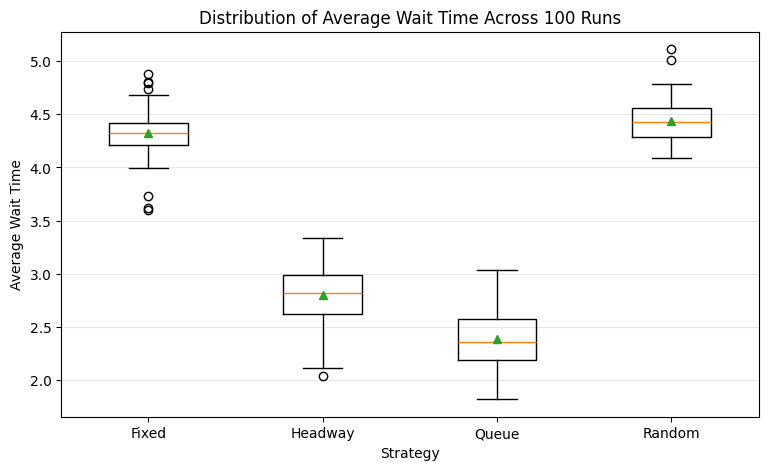

/tmp/ipykernel_28819/1476998153.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


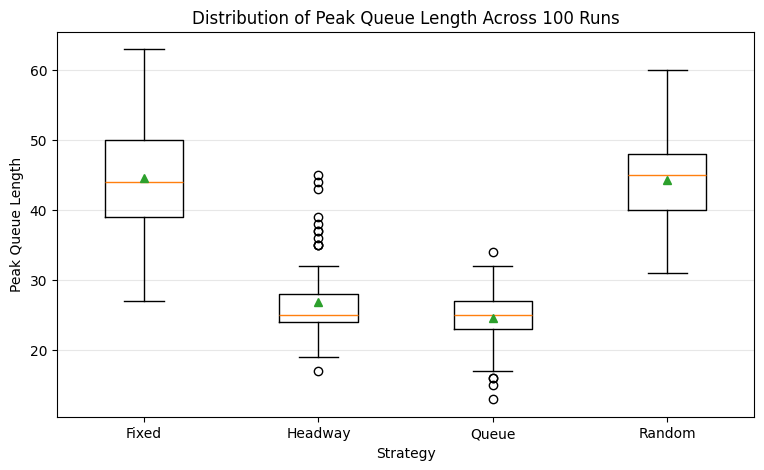

/tmp/ipykernel_28819/1476998153.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


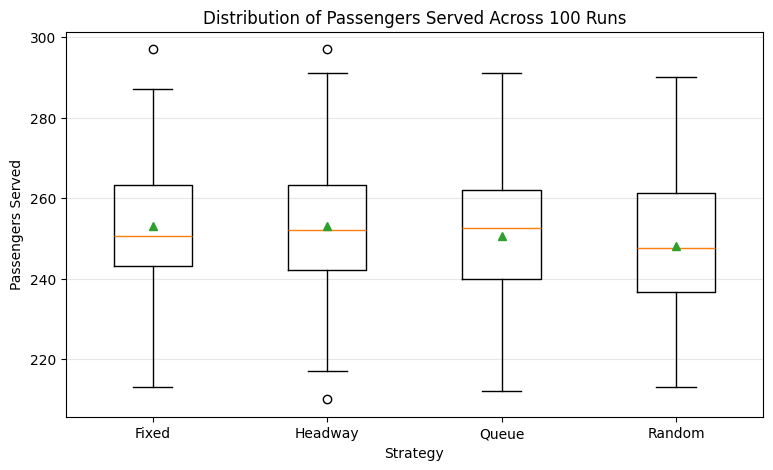

/tmp/ipykernel_28819/1476998153.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


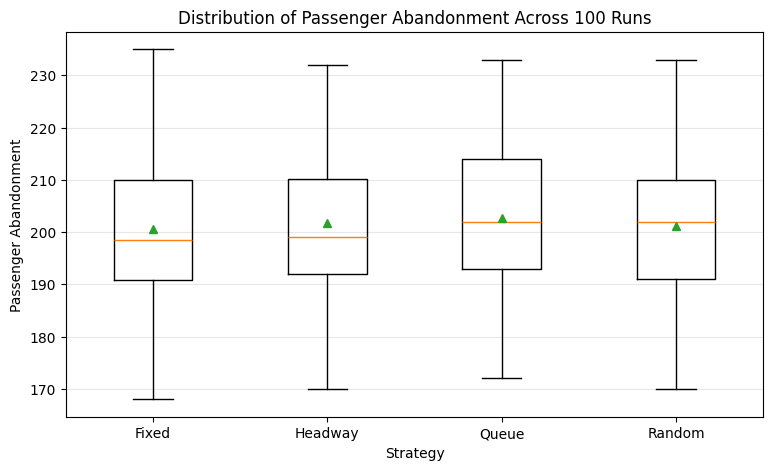

/tmp/ipykernel_28819/1476998153.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


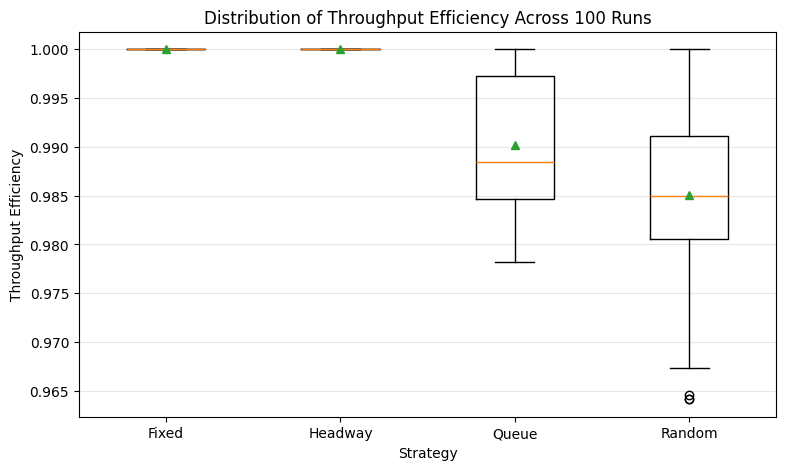

/tmp/ipykernel_28819/1476998153.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


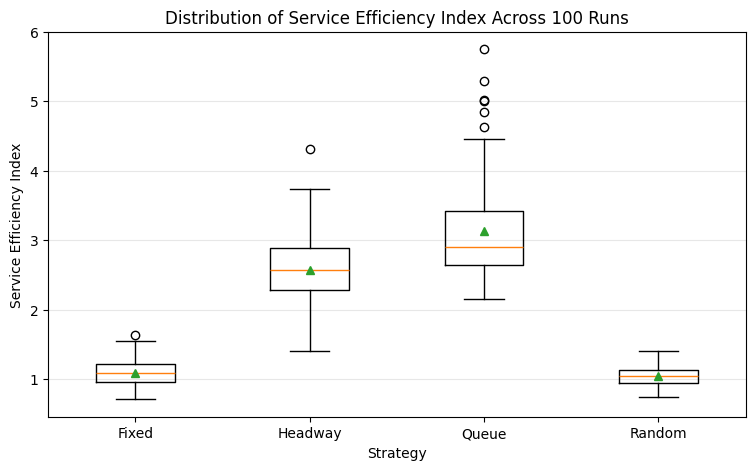

/tmp/ipykernel_28819/1476998153.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


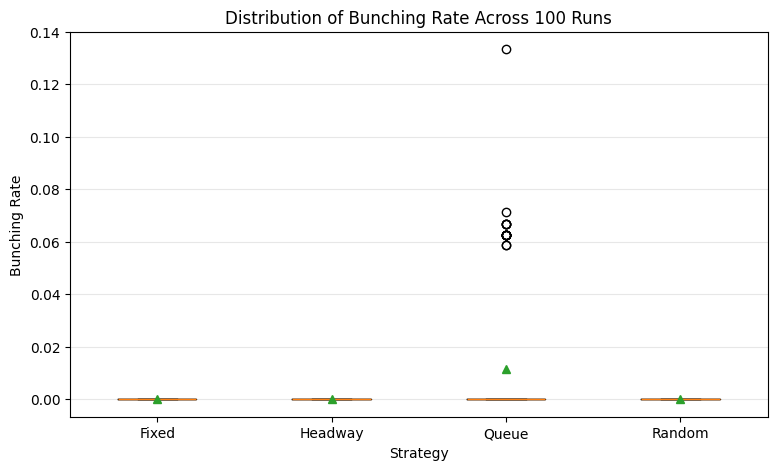

/tmp/ipykernel_28819/1476998153.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


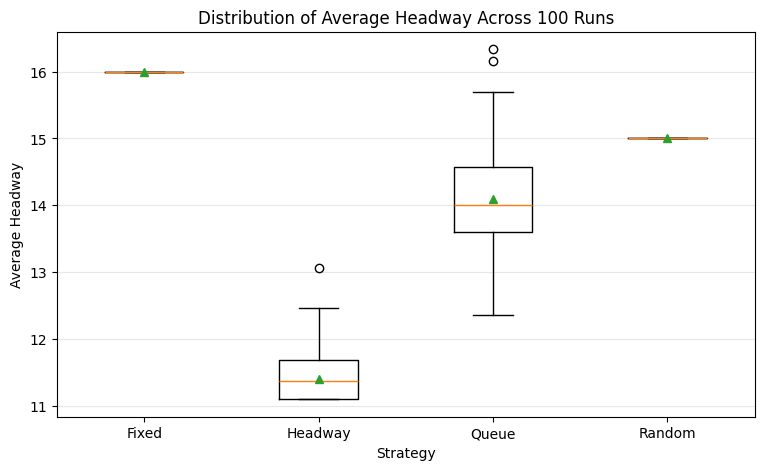

/tmp/ipykernel_28819/1476998153.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


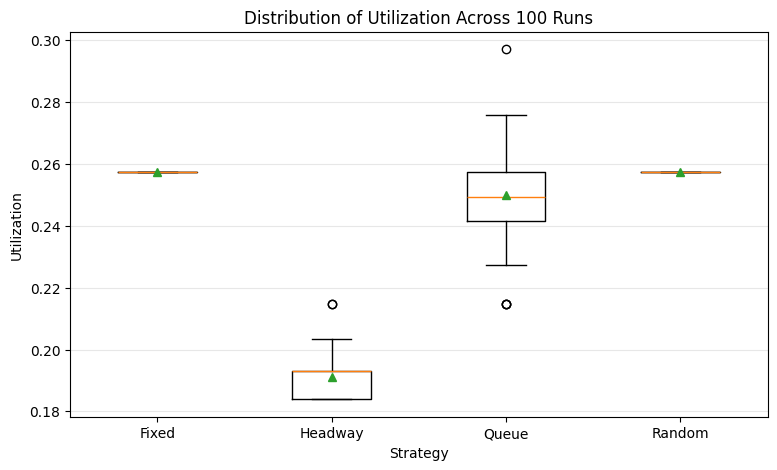

In [87]:
#testing out multi runs
N_RUNS = 100
multi_run_records = []
for run in range(N_RUNS):
    for strategy in STRATEGIES:
        m = EDSABuswayModel(
            strategy=strategy,
            arrival_rate=ARRIVAL_RATE,
            rng=run
        )
        for _ in range(SIM_STEPS):
            m.step()
        avg_wait = m.total_wait_time_served / m.served_count if m.served_count > 0 else 0
        peak_q = max(m.queue_history) if m.queue_history else 0
        throughput = m.served_count / max(1, m.total_passengers_arrived)
        sei = m.served_count / ((avg_wait + 1) * max(1, peak_q))
        bunching_events = sum(m.bunching_history)
        bunching_rate = bunching_events / max(1, m.buses_dispatched)
        avg_hw = np.mean(m.headways) if m.headways else 0
        mu_eff = (BUS_CAPACITY * m.buses_dispatched) / SIM_STEPS
        rho = ARRIVAL_RATE / max(mu_eff, 0.01)
        multi_run_records.append({
            "Run": run + 1,
            "Strategy": strategy.capitalize(),
            "Average Wait Time": avg_wait,
            "Peak Queue Length": peak_q,
            "Passengers Served": m.served_count,
            "Passenger Abandonment": m.abandoned_count,
            "Throughput Efficiency": throughput,
            "Service Efficiency Index": sei,
            "Bunching Events": bunching_events,
            "Bunching Rate": bunching_rate,
            "Average Headway": avg_hw,
            "Utilization": rho
        })
multi_run_df = pd.DataFrame(multi_run_records)
print("MULTI-RUN DISTRIBUTION SUMMARY")
print("=" * 110)
distribution_summary = multi_run_df.groupby("Strategy").agg([
    "mean",
    "std",
    "min",
    "max"
]).round(3)
display(distribution_summary)

# Boxplot comparisons

variables_to_plot = [
    "Average Wait Time",
    "Peak Queue Length",
    "Passengers Served",
    "Passenger Abandonment",
    "Throughput Efficiency",
    "Service Efficiency Index",
    "Bunching Rate",
    "Average Headway",
    "Utilization"
]
for variable in variables_to_plot:
    plt.figure(figsize=(9, 5))
    data_to_plot = [
        multi_run_df[multi_run_df["Strategy"] == strategy.capitalize()][variable]
        for strategy in STRATEGIES
    ]
    plt.boxplot(
        data_to_plot,
        labels=[strategy.capitalize() for strategy in STRATEGIES],
        showmeans=True
    )
    plt.title(f"Distribution of {variable} Across {N_RUNS} Runs")
    plt.xlabel("Strategy")
    plt.ylabel(variable)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# Remarks:

* The graphs used in the presentation have different values due to different parameters used but same trends and analysis apply.
* Queue dependent dispatch rule was also edited after to flat out bus bunching.
* Only one station (index 0: PITX) was considered and checked in the results.
* The random strategy was supposed to be based on the data but instead we used stochastic dispatch intervals to approximate real-world irregularity of dispatching rates.
* Arrival rate was calculated from the data while the Service Rate was adjusted to make it more realistic.